# Załadowanie zbiorów danych oraz bibliotek

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV, cross_val_predict
from sklearn.svm import SVC

from sklearn.metrics import (
    make_scorer,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    fbeta_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc, 
    RocCurveDisplay,
    precision_score,
    recall_score
)

In [3]:
X_train = pd.read_csv("X_train.csv")
y_train = pd.read_csv("y_train.csv")
X_test = pd.read_csv("X_test.csv")
y_test = pd.read_csv("y_test.csv")

y_train = y_train.squeeze()
y_test = y_test.squeeze()

# Kod dotyczący metryk i oceny modelu

In [5]:

def business_profit_score(y_true, y_pred):
    """
    Oblicza zysk biznesowy dla zadania.
    +1 za uratowane życie (True Positive - TP).
    -0.25 za utraconego pacjenta (False Positive - FP),
    ponieważ co czwarty fałszywy alarm pacjent odinstalowujący aplikację.
    """
    _, fp, _, tp = confusion_matrix(y_true, y_pred).ravel()

    return tp - (0.25 * fp)

# Tworzymy obiekt scorer gotowy do użycia
custom_business_scorer = make_scorer(business_profit_score, greater_is_better=True)

# Tworzymy osobną metrykę F2 do śledzenia (Czułość jest dla nas 2x ważniejsza)
f2_scorer = make_scorer(fbeta_score, beta=2)

# Słownik wszystkich metryk do wykorzystania w GridSearchCV (parametr: scoring=scoring_dict)
scoring_dict = {
    'Business_Score': custom_business_scorer,
    'F2_Score': f2_scorer,
    'ROC_AUC': 'roc_auc',
    'PR_AUC': 'average_precision'
}


def evaluate_heart_model(model, X_test, y_test, threshold=0.5):
    """
    Wypisuje pełny raport skuteczności modelu przetestowanego na zbiorze testowym
    uwzględniając próg odcięcia. Wyświetla również macierz pomyłek i krzywą ROC.
    """
    # Pobieramy prawdopodobieństwa (potrzebne do ROC i PR AUC)
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        # Fallback np. dla dec_function
        y_proba = model.decision_function(X_test)
        
    # Predykcje dla zadanego progu
    y_pred = (y_proba >= threshold).astype(int)

    print(f"--- WYNIKI MODELU: SYSTEM OSTRZEGANIA PRZED ZAWAŁEM (Próg: {threshold:.2f}) ---")
    print(f"Zysk Biznesowy (TP - 0.25*FP): {business_profit_score(y_test, y_pred):.2f}")
    print(f"F2-Score (Nacisk na Czułość):  {fbeta_score(y_test, y_pred, beta=2):.4f}")
    print(f"ROC AUC:                       {roc_auc_score(y_test, y_proba):.4f}")
    print(f"PR AUC (Average Precision):    {average_precision_score(y_test, y_proba):.4f}")
    print("\n--- SZCZEGÓŁOWY RAPORT KLASYFIKACJI ---")
    print(classification_report(y_test, y_pred))
    
    # Wykresy
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    # Macierz pomyłek
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=ax[0], cmap='Blues')
    ax[0].set_title(f'Macierz pomyłek (Próg: {threshold:.2f})')

    # Krzywa ROC
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    roc_disp = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, name='Model SVM')
    roc_disp.plot(ax=ax[1])
    ax[1].set_title('Krzywa ROC')

    plt.tight_layout()
    plt.show()

# Zdefiniowanie modelu SVM i jego trenowanie

--- WYNIKI MODELU: SYSTEM OSTRZEGANIA PRZED ZAWAŁEM (Próg: 0.50) ---
Zysk Biznesowy (TP - 0.25*FP): 0.00
F2-Score (Nacisk na Czułość):  0.0000
ROC AUC:                       0.6498
PR AUC (Average Precision):    0.1084

--- SZCZEGÓŁOWY RAPORT KLASYFIKACJI ---
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       972
           1       0.00      0.00      0.00        50

    accuracy                           0.95      1022
   macro avg       0.48      0.50      0.49      1022
weighted avg       0.90      0.95      0.93      1022



c:\Users\ignac\Desktop\notatniki\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ignac\Desktop\notatniki\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ignac\Desktop\notatniki\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res

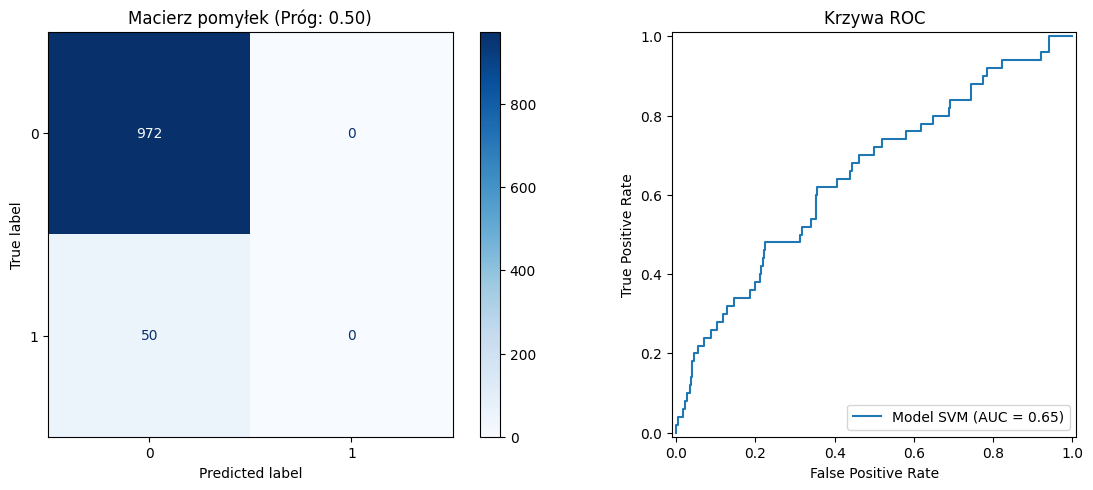

In [6]:
# Model SVM z domyślnymi hiperparametrami
svm_model = SVC(probability=True, random_state=67)
svm_model.fit(X_train, y_train)
evaluate_heart_model(svm_model, X_test, y_test, threshold=0.5)

In [7]:
svm = SVC(random_state=67, probability=True)

param_grid = [
    {'kernel': ['rbf'], 'C': [0.1,1,10,100], 'gamma': ['scale', 'auto'],'class_weight':[None, 'balanced']},
    {'kernel': ['linear'], 'C': [0.1,1,10],'class_weight':[None, 'balanced']},
    {'kernel':['poly'], 'C':[0.1,1,10],'class_weight':[None,'balanced'], 'gamma' : ['scale','auto'], 'degree':[2,3]}
]

grid_search = GridSearchCV(estimator=svm, param_grid=param_grid, scoring=scoring_dict, refit='PR_AUC', cv=5, n_jobs=1, verbose=3)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 46 candidates, totalling 230 fits
[CV 1/5] END C=0.1, class_weight=None, gamma=scale, kernel=rbf; Business_Score: (test=0.000) F2_Score: (test=0.000) PR_AUC: (test=0.089) ROC_AUC: (test=0.651) total time=   1.3s
[CV 2/5] END C=0.1, class_weight=None, gamma=scale, kernel=rbf; Business_Score: (test=0.000) F2_Score: (test=0.000) PR_AUC: (test=0.098) ROC_AUC: (test=0.616) total time=   1.3s
[CV 3/5] END C=0.1, class_weight=None, gamma=scale, kernel=rbf; Business_Score: (test=0.000) F2_Score: (test=0.000) PR_AUC: (test=0.081) ROC_AUC: (test=0.645) total time=   1.1s
[CV 4/5] END C=0.1, class_weight=None, gamma=scale, kernel=rbf; Business_Score: (test=0.000) F2_Score: (test=0.000) PR_AUC: (test=0.116) ROC_AUC: (test=0.602) total time=   1.3s
[CV 5/5] END C=0.1, class_weight=None, gamma=scale, kernel=rbf; Business_Score: (test=0.000) F2_Score: (test=0.000) PR_AUC: (test=0.112) ROC_AUC: (test=0.589) total time=   1.5s
[CV 1/5] END C=0.1, class_weight=None, gamma=aut

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC(probabili...ndom_state=67)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'C': [0.1, 1, ...], 'class_weight': [None, 'balanced'], 'gamma': ['scale', 'auto'], 'kernel': ['rbf']}, {'C': [0.1, 1, ...], 'class_weight': [None, 'balanced'], 'kernel': ['linear']}, ...]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'Business_Score': make_scorer(b...hod='predict'), 'F2_Score': make_scorer(f...dict', beta=2), 'PR_AUC': 'average_precision', 'ROC_AUC': 'roc_auc'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'PR_AUC'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... v

In [11]:


best_model = grid_search.best_estimator_
y_proba_cv = cross_val_predict(best_model, X_train, y_train, cv=5, method='predict_proba', n_jobs=-1)[:, 1]

best_profit = -9999
best_threshold = 0.5
for threshold in np.arange(0.0, 1.01, 0.01):
    y_pred_threshold = (y_proba_cv >= threshold).astype(int)
    profit = business_profit_score(y_train, y_pred_threshold)
    if profit > best_profit:
        best_profit = profit
        best_threshold = threshold

print(f"Optymalny próg decyzyjny (CV) dla maksymalizacji zysku biznesowego: {best_threshold:.2f} (Zysk sumaryczny CV: {best_profit:.2f})")

Optymalny próg decyzyjny (CV) dla maksymalizacji zysku biznesowego: 0.29 (Zysk sumaryczny CV: 10.25)


--- WYNIKI MODELU: SYSTEM OSTRZEGANIA PRZED ZAWAŁEM (Próg: 0.29) ---
Zysk Biznesowy (TP - 0.25*FP): 0.25
F2-Score (Nacisk na Czułość):  0.1116
ROC AUC:                       0.8358
PR AUC (Average Precision):    0.2415

--- SZCZEGÓŁOWY RAPORT KLASYFIKACJI ---
              precision    recall  f1-score   support

           0       0.95      0.98      0.97       972
           1       0.21      0.10      0.14        50

    accuracy                           0.94      1022
   macro avg       0.58      0.54      0.55      1022
weighted avg       0.92      0.94      0.93      1022



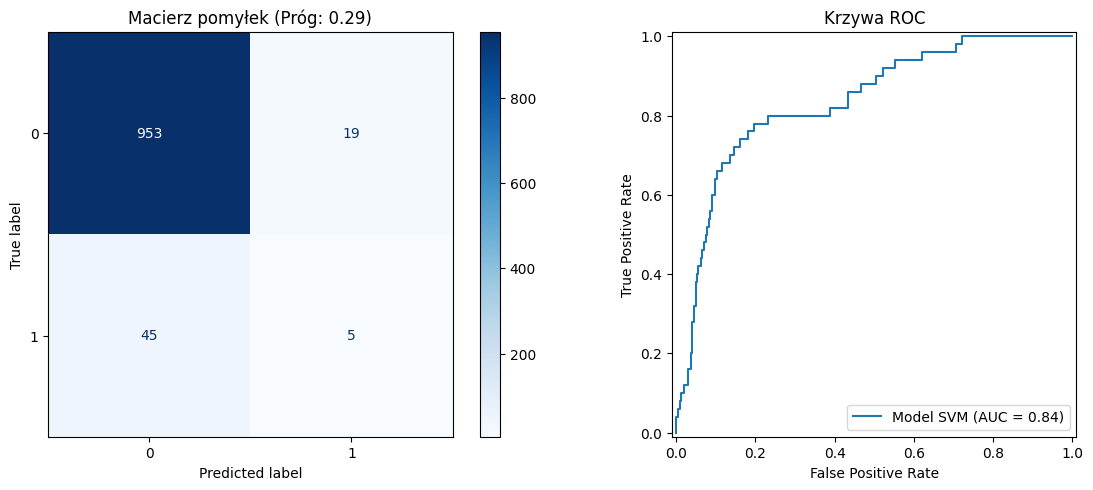

In [12]:
evaluate_heart_model(best_model, X_test, y_test, threshold=best_threshold)

Top 10 konfiguracji modelu wg Business Score:
    C kernel gamma class_weight  degree  Business_Score  F2_Score  ROC_AUC
 10.0   poly scale         None     3.0            0.25  0.041663 0.574638
100.0    rbf  auto         None     NaN            0.15  0.030721 0.622234
  0.1    rbf scale         None     NaN            0.00  0.000000 0.620746
  0.1    rbf  auto         None     NaN            0.00  0.000000 0.636636
  1.0    rbf scale         None     NaN            0.00  0.000000 0.621735
  1.0    rbf  auto         None     NaN            0.00  0.000000 0.617211
 10.0    rbf  auto         None     NaN            0.00  0.000000 0.619222
  0.1 linear  None         None     NaN            0.00  0.000000 0.604848
  1.0 linear  None         None     NaN            0.00  0.000000 0.547608
 10.0 linear  None         None     NaN            0.00  0.000000 0.502384


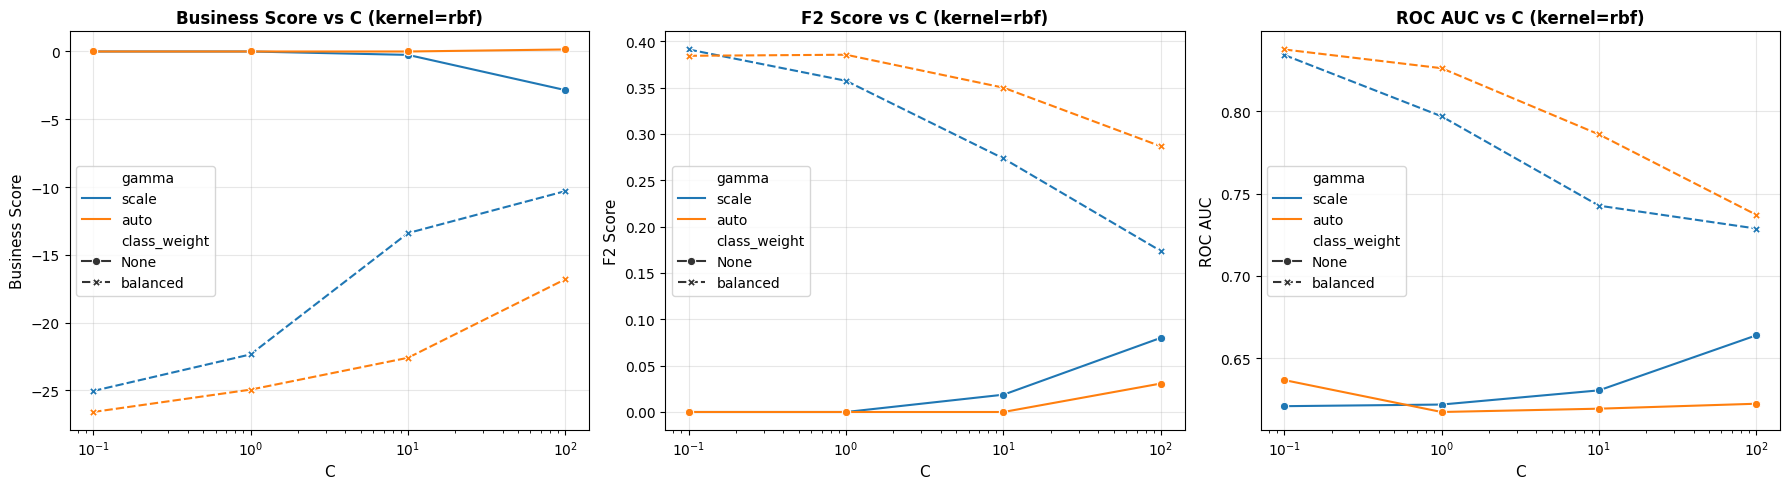

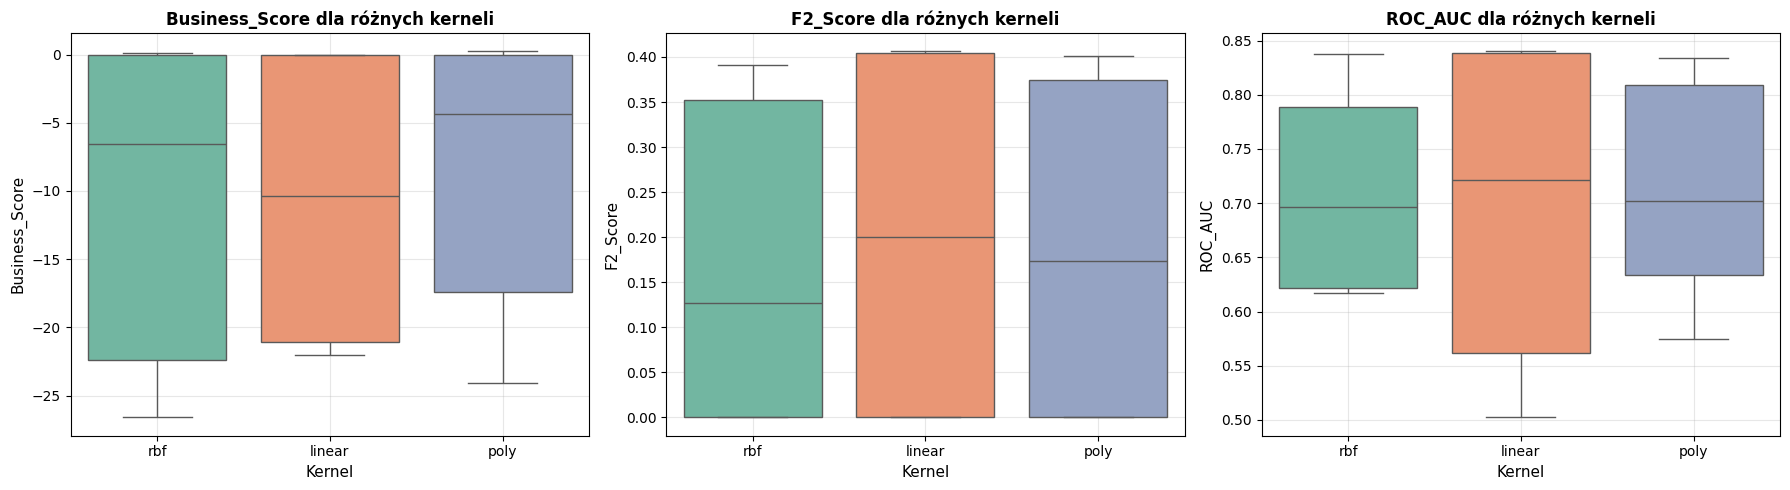

In [10]:
# Wyodrębniamy wyniki z grid search'a
cv_results = grid_search.cv_results_
params_list = cv_results['params']
business_scores_cv = cv_results['mean_test_Business_Score']
f2_scores_cv = cv_results['mean_test_F2_Score']
roc_auc_cv = cv_results['mean_test_ROC_AUC']

# Tworzymy dataframe z wynikami
results_df = pd.DataFrame({
    'C': [p.get('C', None) for p in params_list],
    'kernel': [p.get('kernel', None) for p in params_list],
    'gamma': [p.get('gamma', None) for p in params_list],
    'class_weight': [str(p.get('class_weight', 'None')) for p in params_list],
    'degree': [p.get('degree', None) for p in params_list],
    'Business_Score': business_scores_cv,
    'F2_Score': f2_scores_cv,
    'ROC_AUC': roc_auc_cv
})

# Sortujemy po Business Score i bierzemy top 10
top_results = results_df.nlargest(10, 'Business_Score')

print("Top 10 konfiguracji modelu wg Business Score:")
print(top_results.to_string(index=False))

# Wykresy: wpływ parametrów C, gamma i class_weight (dla kernel='rbf')
rbf_results = results_df[results_df['kernel'] == 'rbf'].copy()

if len(rbf_results) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Używamy seaborn.lineplot dla estetycznego rozdzielenia gamma (kolor) i class_weight (styl linii)
    sns.lineplot(data=rbf_results, x='C', y='Business_Score', hue='gamma', style='class_weight', markers=True, dashes=True, ax=axes[0])
    axes[0].set_xlabel('C', fontsize=11)
    axes[0].set_ylabel('Business Score', fontsize=11)
    axes[0].set_title('Business Score vs C (kernel=rbf)', fontsize=12, fontweight='bold')
    axes[0].set_xscale('log')
    axes[0].grid(True, alpha=0.3)
    
    sns.lineplot(data=rbf_results, x='C', y='F2_Score', hue='gamma', style='class_weight', markers=True, dashes=True, ax=axes[1])
    axes[1].set_xlabel('C', fontsize=11)
    axes[1].set_ylabel('F2 Score', fontsize=11)
    axes[1].set_title('F2 Score vs C (kernel=rbf)', fontsize=12, fontweight='bold')
    axes[1].set_xscale('log')
    axes[1].grid(True, alpha=0.3)
    
    sns.lineplot(data=rbf_results, x='C', y='ROC_AUC', hue='gamma', style='class_weight', markers=True, dashes=True, ax=axes[2])
    axes[2].set_xlabel('C', fontsize=11)
    axes[2].set_ylabel('ROC AUC', fontsize=11)
    axes[2].set_title('ROC AUC vs C (kernel=rbf)', fontsize=12, fontweight='bold')
    axes[2].set_xscale('log')
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Porównanie kerneli za pomocą Boxplotów
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, metric in enumerate(['Business_Score', 'F2_Score', 'ROC_AUC']):
    sns.boxplot(data=results_df, x='kernel', y=metric, hue='kernel', ax=axes[idx], palette='Set2')
    axes[idx].set_ylabel(metric, fontsize=11)
    axes[idx].set_xlabel('Kernel', fontsize=11)
    axes[idx].set_title(f'{metric} dla różnych kerneli', fontsize=12, fontweight='bold')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Ostateczna ocena modelu i wnioski

Model miał zostać użyty w celu rozwiązania konkretnego problemu biznesowego. Na podstawie opisu problemu powstała funkcja oceny modelu TP - 0.25 * FP. Przez silne niezbalansowanie danych (tylko około 5% pozytywnych przykładów), gdy optymalizowałem model pod kątem tej funkcji w GridSearch, to przede wszystkim wygrywały modele, które praktycznie nie przewidywały zawału. W związku z tym wybrałem model, który miał najwyższe PR AUC (pole pod krzywą precyzja-czułość), a następnie dostosowałem próg decyzyjny (threshold), aby zmaksymalizować funkcję oceny. Wyniki, które uzyskałem, na test secie to lekko dodatnia ocena biznesowa.  Jednakowóż jeśli chodzi o zastosowania medyczne, to stoją tu one w sprzeczności z koncepcją biznesową, ponieważ w tym przypadku model musiał się skupiać na tym, by nie dawać za dużo FP, co spowodowało bardzo niski recall (czułość) i w efekcie wiele przypadków zawału zostało niewykrytych. W związku z tym, mimo że model osiągnął pozytywną ocenę biznesową, to jego użyteczność w kontekście medycznym jest bardzo ograniczona. Jeśli chodzi o dobór hiperparametrów, na wykresach widać, że modele bez balansowania klas miały lepsze wyniki metryki biznesowej (około 0), bo po prostu ignorowały pozytywne przypadki. Generalnie z balansowaniem klas, modele osiągały lepsze wyniki (ROC AUC i F2), jednak spadały one z rośnięciem parametru C, dokładnie odwrotnie do metryki biznesowej. Analiza rozkładu wyników różnych kerneli wykazała, że choć jądro liniowe miało największy potencjał klasyfikacyjny (maksima ROC AUC), to z uwagi na jego niestabilność, najbezpieczniejszym wyborem optymalizującym Zysk Biznesowy okazało się jądro wielomianowe. Jednocześnie niska baza wyników wymusiła na nas do dostrojenia progu decyzyjnego.